**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 2**
Pandas para el análisis de datos en Python

---

*   NOMBRE: Carlos Rodrigo Salguero Alcantara
*   MATRÍCULA: A00833341


---

En esta actividad trabajarás con el archivo `cleaned_weather.csv`, un extracto del conjunto de datos meteorológicos a lo largo de todo el año 2020 en una estación del Instituto *Max Planck* (Alemania) disponible en Kaggle.

Los datos meteorológicos fueron registrados cada 10 minutos e incluyen los siguientes indicadores:

*   `timestamp`: Fecha y hora de la observación.
*   `p`: Presión atmosférica en milibares (mbar)
*   `T`: Temperatura del aire en grados Celsius (°C)
*   `Tpot`: Temperatura potencial en Kelvin (K)
*   `rh`: Humedad relativa en porcentaje (%)
*   `VPact`: Presión real de vapor en milibares (mbar)
*   `sh`: Humedad específica en gramos por kilogramo (g/kg)
*   `H2OC`: Concentración de vapor de agua en milimoles por mol (mmol/mol) de aire seco
*   `rho`: Densidad del aire en gramos por metro cúbico (g/m³)
*   `wv`: Velocidad del viento en metros por segundo (m/s)
*   `wd`: Dirección del viento en grados (°)
*   `rain`: Precipitación total en milímetros (mm)
*   `raining`: Duración de la lluvia en segundos (s)

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.


In [35]:
# Importa las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

1.	Descarga el archivo: `cleaned_weather.csv` y guarda, en un dataframe (`weather_df`), todos sus registros.
- Determina la dimensionalidad del dataframe y obtén los identificadores de columnas.
- Renombra las columnas para facilitar la interpretación de los indicadores en los ejercicios siguientes:
  - `medicion, presion_atmosferica, temperatura_celsius, temperatura_kelvin, humedad_relativa, presion_vapor, humedad_especifica, concentracion_vapor, densidad_aire, velocidad_viento, direccion_viento, precipitacion_total, duracion_lluvia`
- Muestra los primeros y los últimos 5 registros.
- ¿Hay valores faltantes en el dataframe?





In [36]:
weather_df = pd.read_csv("data/cleaned_weather.csv")
print(weather_df.head())

       timestamp        p     T    Tpot    rh  VPact    sh  H2OC      rho  \
0  01/01/20 0:10  1008.89  0.71  273.18  86.1   5.54  3.42  5.49  1280.62   
1  01/01/20 0:20  1008.76  0.75  273.22  85.2   5.49  3.39  5.45  1280.33   
2  01/01/20 0:30  1008.66  0.73  273.21  85.1   5.48  3.39  5.43  1280.29   
3  01/01/20 0:40  1008.64  0.37  272.86  86.3   5.41  3.35  5.37  1281.97   
4  01/01/20 0:50  1008.61  0.33  272.82  87.4   5.47  3.38  5.42  1282.08   

     wv     wd  rain  raining  
0  1.02  224.3   0.0        0  
1  0.43  206.8   0.0        0  
2  0.61  197.1   0.0        0  
3  1.11  206.4   0.0        0  
4  0.49  209.6   0.0        0  


In [37]:
print(weather_df.shape)

(52696, 13)


In [38]:
print(weather_df.columns.tolist())

['timestamp', 'p', 'T', 'Tpot', 'rh', 'VPact', 'sh', 'H2OC', 'rho', 'wv', 'wd', 'rain', 'raining']


In [39]:
columns = [
   "medicion",
    "presion_atmosferica",
    "temperatura_celsius",
    "temperatura_kelvin",
    "humedad_relativa",
    "presion_vapor",
    "humedad_especifica",
    "concentracion_vapor",
    "densidad_aire",
    "velocidad_viento",
    "direccion_viento",
    "precipitacion_total",
    "duracion_lluvia"
]

In [40]:
weather_df.columns = columns
print(weather_df.head())


        medicion  presion_atmosferica  temperatura_celsius  \
0  01/01/20 0:10              1008.89                 0.71   
1  01/01/20 0:20              1008.76                 0.75   
2  01/01/20 0:30              1008.66                 0.73   
3  01/01/20 0:40              1008.64                 0.37   
4  01/01/20 0:50              1008.61                 0.33   

   temperatura_kelvin  humedad_relativa  presion_vapor  humedad_especifica  \
0              273.18              86.1           5.54                3.42   
1              273.22              85.2           5.49                3.39   
2              273.21              85.1           5.48                3.39   
3              272.86              86.3           5.41                3.35   
4              272.82              87.4           5.47                3.38   

   concentracion_vapor  densidad_aire  velocidad_viento  direccion_viento  \
0                 5.49        1280.62              1.02             224.3   
1   

In [41]:
print(weather_df.tail())

             medicion  presion_atmosferica  temperatura_celsius  \
52691  31/12/20 23:20               978.32                 2.28   
52692  31/12/20 23:30               978.30                 2.13   
52693  31/12/20 23:40               978.26                 1.99   
52694  31/12/20 23:50               978.26                 2.07   
52695   01/01/21 0:00               978.24                 2.01   

       temperatura_kelvin  humedad_relativa  presion_vapor  \
52691              277.16              80.0           5.76   
52692              277.01              83.1           5.92   
52693              276.88              82.2           5.80   
52694              276.95              81.4           5.77   
52695              276.89              82.4           5.82   

       humedad_especifica  concentracion_vapor  densidad_aire  \
52691                3.67                 5.89        1234.61   
52692                3.77                 6.05        1235.20   
52693                3.69    

In [42]:
print(weather_df.isnull().sum())

medicion               0
presion_atmosferica    0
temperatura_celsius    0
temperatura_kelvin     0
humedad_relativa       0
presion_vapor          0
humedad_especifica     0
concentracion_vapor    0
densidad_aire          0
velocidad_viento       0
direccion_viento       0
precipitacion_total    0
duracion_lluvia        0
dtype: int64


No hay valores faltantes en el dataset.


2. Determina el tipo de datos que tienen las columnas.
- Cambia la columna `medicion` a datetime utilizando el formato: `%d/%m/%y %H:%M`
- Obtén dos columnas adicionales separando `medicion` en `fecha` y `hora`

In [43]:
print(weather_df.dtypes)

medicion                   str
presion_atmosferica    float64
temperatura_celsius    float64
temperatura_kelvin     float64
humedad_relativa       float64
presion_vapor          float64
humedad_especifica     float64
concentracion_vapor    float64
densidad_aire          float64
velocidad_viento       float64
direccion_viento       float64
precipitacion_total    float64
duracion_lluvia          int64
dtype: object


In [44]:
weather_df['medicion'] = pd.to_datetime(
  weather_df['medicion'], format='%d/%m/%y %H:%M',
)

In [45]:
weather_df['fecha'] = weather_df['medicion'].dt.date
weather_df['hora'] = weather_df['medicion'].dt.time

In [46]:
print(weather_df.head())

             medicion  presion_atmosferica  temperatura_celsius  \
0 2020-01-01 00:10:00              1008.89                 0.71   
1 2020-01-01 00:20:00              1008.76                 0.75   
2 2020-01-01 00:30:00              1008.66                 0.73   
3 2020-01-01 00:40:00              1008.64                 0.37   
4 2020-01-01 00:50:00              1008.61                 0.33   

   temperatura_kelvin  humedad_relativa  presion_vapor  humedad_especifica  \
0              273.18              86.1           5.54                3.42   
1              273.22              85.2           5.49                3.39   
2              273.21              85.1           5.48                3.39   
3              272.86              86.3           5.41                3.35   
4              272.82              87.4           5.47                3.38   

   concentracion_vapor  densidad_aire  velocidad_viento  direccion_viento  \
0                 5.49        1280.62              

3. Determina la cantidad de valores únicos de cada columna.
- La columna `medicion` tiene un valor menos que el número total de filas del dataframe, lo que indica que hay una fecha duplicada. Identifica cuál es.
- Comprueba si las demás columnas también contienen los mismos valores; si es así, elimina  uno de los registros duplicados.


In [47]:
print(weather_df.nunique())

medicion               52695
presion_atmosferica     5052
temperatura_celsius     3680
temperatura_kelvin      3836
humedad_relativa        5494
presion_vapor           2059
humedad_especifica      1337
concentracion_vapor     2087
densidad_aire          14826
velocidad_viento         977
direccion_viento        8099
precipitacion_total       42
duracion_lluvia           61
fecha                    367
hora                     144
dtype: int64


In [48]:
duplicated_mask = weather_df['medicion'].duplicated(keep=False)
print(weather_df[duplicated_mask])

                 medicion  presion_atmosferica  temperatura_celsius  \
19043 2020-05-12 06:00:00               991.53                -1.57   
19044 2020-05-12 06:00:00               991.53                -1.57   

       temperatura_kelvin  humedad_relativa  presion_vapor  \
19043              272.25              96.2           5.24   
19044              272.25              96.2           5.24   

       humedad_especifica  concentracion_vapor  densidad_aire  \
19043                3.29                 5.28        1269.29   
19044                3.29                 5.28        1269.29   

       velocidad_viento  direccion_viento  precipitacion_total  \
19043              1.04             215.4                  0.0   
19044              1.04             215.4                  0.0   

       duracion_lluvia       fecha      hora  
19043                0  2020-05-12  06:00:00  
19044                0  2020-05-12  06:00:00  


In [49]:
weather_df = weather_df.drop_duplicates()

4. Imprime nuevamente las cantidad de valores únicos por columna.
- ¿Por qué son 144 horas diferentes?
- La cantidad de combinaciones únicas de fecha y hora no coincide con el número total de mediciones. Aunque no haya valores NaN, esto no garantiza que no se hayan omitido registros. Identifica las fechas en las que faltan mediciones.
- Una vez concluido el análisis de mediciones faltantes, elimina todos los registros que no correspondan al año 2020 y la columna `medicion`.


In [50]:
print(weather_df.nunique())

medicion               52695
presion_atmosferica     5052
temperatura_celsius     3680
temperatura_kelvin      3836
humedad_relativa        5494
presion_vapor           2059
humedad_especifica      1337
concentracion_vapor     2087
densidad_aire          14826
velocidad_viento         977
direccion_viento        8099
precipitacion_total       42
duracion_lluvia           61
fecha                    367
hora                     144
dtype: int64


In [51]:
expected_freq = pd.date_range(
  start=weather_df['medicion'].min(),
  end=weather_df['medicion'].max(),
  freq='10min'
)

missing = expected_freq.difference(weather_df['medicion'])
missing_dates = pd.Series(missing.date).unique()

print(f"Dates with missing records: {missing_dates}")

Dates with missing records: [datetime.date(2020, 5, 29)]


La fecha con mediciones faltantes es el 2020-05-29.

In [52]:
weather_df = weather_df[weather_df['medicion'].dt.year == 2020]
weather_df = weather_df.drop(columns=['medicion'])

Existen 144 combinaciones únicas de hora porque las mediciones se registran cada 10 minutos. Siguiendo la siguiente fórmula:

$$
6 \text{ registros por hora} \times 24 \text{ horas} = 144 \text{ registros posibles por día}
$$

5. Obtén un dataframe `indicadores_diarios` que sólo almacene el mayor valor de las mediciones por fecha para responder:
- ¿Cuál fue la máxima precipitación y a qué fecha pertenece?
- ¿Cuáles fueron los tres días con las velocidades de viento más altas registradas?
- ¿Cuántos días rebasaron el 90% de humedad relativa y los 30° celsius?

In [53]:
indicadores_diarios = weather_df.groupby('fecha').max()

In [54]:
max_rain = indicadores_diarios['precipitacion_total'].idxmax()
max_rain_value = indicadores_diarios['precipitacion_total'].max()

print(f"Max rain: {max_rain_value} on {max_rain}")

Max rain: 11.2 on 2020-06-16


In [55]:
top_windiest_days = indicadores_diarios["velocidad_viento"].nlargest(3)
print(f"Top 3 windiest days: {top_windiest_days}")

Top 3 windiest days: fecha
2020-02-10    13.77
2020-02-16    13.00
2020-02-09    12.52
Name: velocidad_viento, dtype: float64


In [56]:
mask = (
    indicadores_diarios['humedad_relativa'] > 90) & \
    (indicadores_diarios['temperatura_celsius'] > 30
)

print(mask.sum())

5


- La máxima precipitación fue de **11.2** mm el 2020-06-16.
- Los tres días con mayor velocidad de viento fueron: 2020-02-10, 2020-02-16 y 2020-02-09.
- **5 días rebasaron** el 90% de humedad relativa y los 30° celsius simultáneamente.

6. La función `describe()` resume múltiples estadísticas descriptivas. Utiliza esta función para explorar y responder las preguntas sobre las variables en el dataframe de `indicadores_diarios `:
- ¿Cuál es la desviación estándar de la concentración de vapor y qué indica?
- ¿Cuál es la mediana de la presión atmosférica y qué significa?
- ¿Cuál es el tercer cuartil de la duración de la lluvia y cómo se interpreta?

In [57]:
desc = indicadores_diarios.describe()
print(desc)

       presion_atmosferica  temperatura_celsius  temperatura_kelvin  \
count           366.000000           366.000000          366.000000   
mean            992.977842            15.343770          289.431667   
std               8.543447             7.850339            7.942175   
min             959.900000            -0.120000          273.460000   
25%             988.015000             8.840000          282.732500   
50%             993.300000            15.060000          289.160000   
75%             998.432500            21.695000          295.957500   
max            1020.070000            34.800000          309.130000   

       humedad_relativa  presion_vapor  humedad_especifica  \
count        366.000000     366.000000          366.000000   
mean          90.886530      11.409454            7.214016   
std            9.201588       4.507555            2.872647   
min           55.440000       3.320000            2.050000   
25%           85.400000       7.647500            

In [58]:
print(f"Std of vapor concentration: {desc.loc['std', 'concentracion_vapor']}")
print(f"Median of atmospheric pressure: {desc.loc['50%', 'presion_atmosferica']}")
print(f"Third quartile of rain duration: {desc.loc['75%', 'duracion_lluvia']}")


Std of vapor concentration: 4.573267035838974
Median of atmospheric pressure: 993.3
Third quartile of rain duration: 600.0


- **Desviación estándar de `concentración_vapor`**: El valor de 4.57 indica una variabilidad significativa en la concentración de vapor en el tiempo, probablemente impulsada por los cambios estacionales de temperatura y humedad.
- **Mediana de `presion_atmosferica**: El valor de 993.3 mbar indica que el 50% de los días registro una presión atmosférica máxima por debajo de este valor. Es una medida de tendencia central más robusta que el promedio ante valores extremos.
- **Tercer cuartil de `duracion_lluvia`**: El 75% de los días tuvo una duración máxima de lluvia de 600 segundos o menos. Dado que este valor parece ser el valor máximo registrado, indica que muchos días lluviosos alcanzaron el límite del sensor o que exista un error en la medición de los datos (datos truncados).


7.	Dibuja un histograma para cada una de las columnas de `indicadores_diarios`.

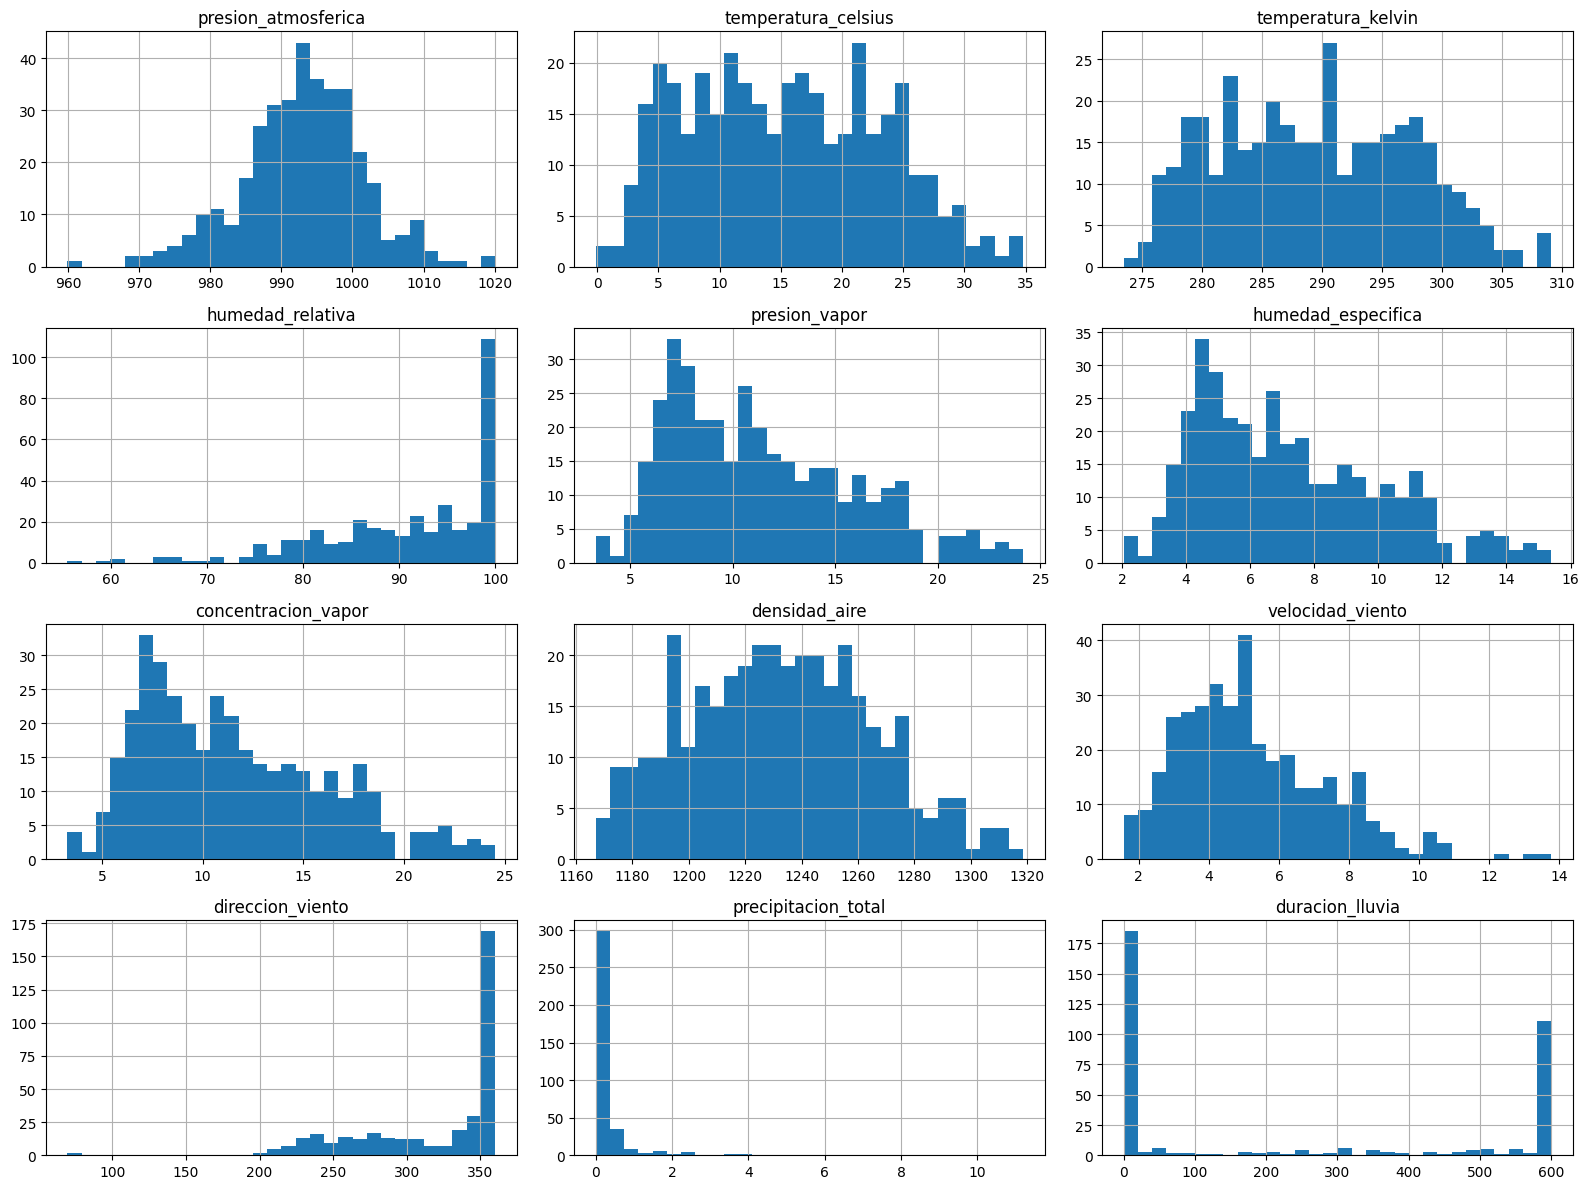

In [59]:
indicadores_diarios.hist(figsize=(16, 12), bins=30)
plt.tight_layout()
plt.show()

8. Utiliza el dataframe de indicadores diarios para crear un nuevo dataframe `indicadores_mensuales`. Para ello:
- Crea una nueva columna `mes` a partir de la fecha que se encuentra en el índice.
- Haciendo uso de `groupby()`, calcula los promedios mensuales y conserva únicamente las columnas `humedad_relativa`, `temperatura_celsius` y `velocidad_viento` en el nuevo dataframe.

In [60]:
indicadores_diarios["mes"] = pd.to_datetime(indicadores_diarios.index).month
indicadores_mensuales = (
  indicadores_diarios
    .groupby("mes")[["humedad_relativa", "temperatura_celsius", "velocidad_viento"]]
    .mean()
)

print(indicadores_mensuales)

     humedad_relativa  temperatura_celsius  velocidad_viento
mes                                                         
1           89.776129             6.821290          5.031935
2           85.719655             8.962414          7.489655
3           85.372903             9.683871          6.421290
4           80.938667            16.879667          4.997000
5           87.464839            17.135484          4.865806
6           94.256000            22.212000          5.296667
7           85.959355            24.336129          4.830323
8           92.002581            26.097742          5.040323
9           97.570000            21.571667          4.153333
10          96.950645            14.089355          5.675484
11          96.983333            10.561667          4.399000
12          97.510968             5.680000          4.817097


9. Construye el mismo dataframe mensual, pero esta vez utilizando la función `pivot_table()`.
- Añade la columna `indice_calor` usando la fórmula de Thom (*Temperature - Humidity Index*, TDI):
> `temperatura_celsius + 0.33 x humedad_relativa - 0.7 x velocidad_viento - 4`

In [61]:
indicadores_diarios["mes"] = pd.to_datetime(indicadores_diarios.index).month
indicadores_mensuales = pd.pivot_table(
  indicadores_diarios,
  index="mes",
  values=["humedad_relativa", "temperatura_celsius", "velocidad_viento"],
  aggfunc="mean"
)

# Thom's Heat Index
indicadores_mensuales["indice_calor"] = (
  indicadores_mensuales["temperatura_celsius"]
  + 0.33 * indicadores_mensuales["humedad_relativa"]
  - 0.7 * indicadores_mensuales["velocidad_viento"]
  - 4
)

print(indicadores_mensuales)

     humedad_relativa  temperatura_celsius  velocidad_viento  indice_calor
mes                                                                       
1           89.776129             6.821290          5.031935     28.925058
2           85.719655             8.962414          7.489655     28.007141
3           85.372903             9.683871          6.421290     29.362026
4           80.938667            16.879667          4.997000     36.091527
5           87.464839            17.135484          4.865806     38.592816
6           94.256000            22.212000          5.296667     45.608813
7           85.959355            24.336129          4.830323     45.321490
8           92.002581            26.097742          5.040323     48.930368
9           97.570000            21.571667          4.153333     46.862433
10          96.950645            14.089355          5.675484     38.110229
11          96.983333            10.561667          4.399000     35.486867
12          97.510968    

10. Recuerda que de las cuatro funciones estudiadas para manipular la estructura del dataframe:
- `melt/pivot` hacen las transformaciones de manera controlada, es decir puedes
definir por medio de sus parámetros qué variables quedarán como índices, columnas y valores.
- `stack/unstack` la conversión se aplica siempre sobre los niveles inferiores de index/columns.
- Convierte el dataframe del ejercicio anterior a formato largo usando: `melt()` y `stack()` y comenta las diferencias.

In [62]:
df_reset = indicadores_mensuales.reset_index()
df_melt = df_reset.melt(id_vars="mes", var_name="indicador", value_name="valor")
print(df_melt)

    mes            indicador      valor
0     1     humedad_relativa  89.776129
1     2     humedad_relativa  85.719655
2     3     humedad_relativa  85.372903
3     4     humedad_relativa  80.938667
4     5     humedad_relativa  87.464839
5     6     humedad_relativa  94.256000
6     7     humedad_relativa  85.959355
7     8     humedad_relativa  92.002581
8     9     humedad_relativa  97.570000
9    10     humedad_relativa  96.950645
10   11     humedad_relativa  96.983333
11   12     humedad_relativa  97.510968
12    1  temperatura_celsius   6.821290
13    2  temperatura_celsius   8.962414
14    3  temperatura_celsius   9.683871
15    4  temperatura_celsius  16.879667
16    5  temperatura_celsius  17.135484
17    6  temperatura_celsius  22.212000
18    7  temperatura_celsius  24.336129
19    8  temperatura_celsius  26.097742
20    9  temperatura_celsius  21.571667
21   10  temperatura_celsius  14.089355
22   11  temperatura_celsius  10.561667
23   12  temperatura_celsius   5.680000


In [63]:
df_stack = indicadores_mensuales.stack()
print(df_stack)

mes                     
1    humedad_relativa       89.776129
     temperatura_celsius     6.821290
     velocidad_viento        5.031935
     indice_calor           28.925058
2    humedad_relativa       85.719655
     temperatura_celsius     8.962414
     velocidad_viento        7.489655
     indice_calor           28.007141
3    humedad_relativa       85.372903
     temperatura_celsius     9.683871
     velocidad_viento        6.421290
     indice_calor           29.362026
4    humedad_relativa       80.938667
     temperatura_celsius    16.879667
     velocidad_viento        4.997000
     indice_calor           36.091527
5    humedad_relativa       87.464839
     temperatura_celsius    17.135484
     velocidad_viento        4.865806
     indice_calor           38.592816
6    humedad_relativa       94.256000
     temperatura_celsius    22.212000
     velocidad_viento        5.296667
     indice_calor           45.608813
7    humedad_relativa       85.959355
     temperatura_celsius 

## Melt

`melt()` toma las columnas de un DataFrame y las convierte en filas (pasando de un formato ancho [muchas columnas] a uno largo [con muchas filas]). La operación comprime la información permitiendo leer, filtrar y manipular los datos de manera sencilla.


## Stack

`stack()` apila las columnas de un DataFrame en una sola columna, creando un MultiIndex (índice múltiple), resultando en una estructura más compacta pero menos legible.


---

**Declaración de uso de IA**


* Anthropic. (2026). Claude Sonnet 4.5 [Modelo de Lenguaje Grande], utilizado para revisión final del documento. https://claude.ai

---